# Evil Twin Attack Detection — Consolidated Model Comparison (session-aware CV)

Summary notebook building on `01_eda_and_prototyping.ipynb`. For each of the 9 models
tuned separately in `legacy_tuning/*.ipynb`, this notebook runs **nested, session-aware
cross-validation** on both the original 4 features (`s1..s4`) and the 13
feature-engineered features (6 pairwise deltas + 3 aggregates), for all three cascade
tasks (Attack Detection, Point Prediction, Antenna Prediction).

**Why this replaces the old procedure.** The dataset is not i.i.d. rows: it consists of
48 attack sessions of ~11-19 rows each (a ~55s window resampled onto a 5s grid), plus 49
no-attack gaps. A row-shuffled `train_test_split` or a shuffled K-fold puts near-identical
rows of the same session into both train and test, so a model can partly recognise the
*session* instead of generalising — this inflated the old Point/Antenna numbers
substantially (see `03_protocol_comparison.ipynb` for a direct side-by-side).

**Evaluation method (see `../src/eval_protocol.py` for the full implementation):**
- Outer CV: `LeaveOneGroupOut` on a task-specific group column so that no session ever
  straddles a train/test boundary — Attack Detection groups by antenna *block* (6 folds),
  Point Prediction by *antenna* (6 folds), Antenna Prediction by *point* (8 folds).
- Inner CV: nested hyperparameter search (`GridSearchCV`, or `RandomizedSearchCV` for the
  three boosting models, whose grids are too large for nested grid search) with
  `GroupKFold` on the same group type, fit only on the outer-fold's training data.
- All reported confusion matrices and the "Pooled Acc" column are built from
  concatenated out-of-fold (OOF) predictions across the outer folds, so
  `trace(CM)/sum(CM)` reproduces the reported accuracy exactly.

GaussianNB/LDA/QDA are excluded, as in the previous version of this notebook — they have
almost no hyperparameters to search over (see `01_eda_and_prototyping.ipynb`).

## 1. Imports & Configuration

In [1]:
import sys, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd().parent / "src"))
import eval_protocol as ep

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'font.size': 16,
    'axes.labelsize': 16,
    'axes.titlesize': 17,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14,
    'figure.dpi': 320,
    'savefig.dpi': 320,
})

REPO_ROOT = ep._find_repo_root()
RESULTS_DIR = REPO_ROOT / "results"
FIGURES_DIR = REPO_ROOT / "figures"
INTERNAL_FIGURES_DIR = FIGURES_DIR / "internal"
RESULTS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)
INTERNAL_FIGURES_DIR.mkdir(exist_ok=True)

## 2. Load Dataset & Build ML Dataset

Same resampling pipeline as before (median resample -> nearest-interpolate -> inner join
across sensors -> `merge_asof` labels), now also attaching the `session`/`block` group
columns used by the evaluation protocol (see section 2.1 of the response-letter note /
`add_groups()` in `eval_protocol.py`).

In [2]:
raw = ep.load_raw()
dataset, info = ep.build_dataset(raw, freq="5s")

print(f"Dataset shape: {dataset.shape}")
print(f"Attack rows: {info.n_attack_rows}  |  Attack sessions: {info.n_sessions_attack}")
print(f"Imputed share per sensor (grid points filled by nearest-value interpolation):")
for sensor, share in info.imputed_share.items():
    print(f"  {sensor}: {share:.3f}")
print(f"Rows per attack session: min={info.rows_per_session[info.rows_per_session.index.isin(dataset.loc[dataset.attack==1,'session'].unique())].min()}, "
      f"max={info.rows_per_session[info.rows_per_session.index.isin(dataset.loc[dataset.attack==1,'session'].unique())].max()}")
dataset.head()

Dataset shape: (2131, 10)
Attack rows: 571  |  Attack sessions: 48
Imputed share per sensor (grid points filled by nearest-value interpolation):
  s1: 0.333
  s2: 0.320
  s3: 0.332
  s4: 0.334
Rows per attack session: min=11, max=19


,time,s1,s2,s3,s4,point,attack,antenna,session,block
0,2026-05-23 14:30:05+03:00,-56.0,-54.0,-62.0,-60.0,0,0,0,1,1
1,2026-05-23 14:30:10+03:00,-55.0,-54.0,-64.0,-60.0,0,0,0,1,1
2,2026-05-23 14:30:15+03:00,-56.0,-53.0,-55.0,-60.0,0,0,0,1,1
3,2026-05-23 14:30:20+03:00,-56.0,-54.0,-55.0,-59.0,0,0,0,1,1
4,2026-05-23 14:30:25+03:00,-55.0,-54.0,-57.0,-61.0,0,0,0,1,1


## 3. Feature Engineering

Same feature engineering as in all `legacy_tuning/*_fe.ipynb` notebooks: 6 pairwise
deltas between sensors + 3 aggregates (`mean_rssi`, `std_rssi`, `range_rssi`).

In [3]:
dataset = ep.add_fe(dataset)

print(f"Base features ({len(ep.FEATURES_BASE)}): {ep.FEATURES_BASE}")
print(f"FE features ({len(ep.FEATURES_FE)}): {ep.FEATURES_FE}")
dataset.head()

Base features (4): ['s1', 's2', 's3', 's4']
FE features (13): ['s1', 's2', 's3', 's4', 'd12', 'd13', 'd14', 'd23', 'd24', 'd34', 'mean_rssi', 'std_rssi', 'range_rssi']


,time,s1,s2,s3,s4,point,attack,antenna,session,block,d12,d13,d14,d23,d24,d34,mean_rssi,std_rssi,range_rssi
0,2026-05-23 14:30:05+03:00,-56.0,-54.0,-62.0,-60.0,0,0,0,1,1,-2.0,6.0,4.0,8.0,6.0,-2.0,-58.00,3.651484,8.0
1,2026-05-23 14:30:10+03:00,-55.0,-54.0,-64.0,-60.0,0,0,0,1,1,-1.0,9.0,5.0,10.0,6.0,-4.0,-58.25,4.645787,10.0
2,2026-05-23 14:30:15+03:00,-56.0,-53.0,-55.0,-60.0,0,0,0,1,1,-3.0,-1.0,4.0,2.0,7.0,5.0,-56.00,2.943920,7.0
3,2026-05-23 14:30:20+03:00,-56.0,-54.0,-55.0,-59.0,0,0,0,1,1,-2.0,-1.0,3.0,1.0,5.0,4.0,-56.00,2.160247,5.0
4,2026-05-23 14:30:25+03:00,-55.0,-54.0,-57.0,-61.0,0,0,0,1,1,-1.0,2.0,6.0,3.0,7.0,4.0,-56.75,3.095696,7.0


## 4. Cascade Task Data

Attack Detection is trained on the full dataset; Point/Antenna Prediction only on attack
samples. Group columns for the **primary** protocol: `block` for Attack Detection,
`antenna` for Point Prediction, `point` for Antenna Prediction (leave-one-group-out in
each case, so the held-out fold always uses hardware / a time block / a position unseen
in training).

In [4]:
FEATURE_SETS = {"Base (4)": ep.FEATURES_BASE, "FE (13)": ep.FEATURES_FE}

for task in ep.TASKS_ORDER:
    spec = ep.TASKS[task]
    mask = spec["rows"](dataset)
    group_col = ep.PROTOCOLS["primary"].group_col_by_task[task]
    print(f"{spec['label']:<22} rows={mask.sum():<5} classes={dataset.loc[mask, spec['y_col']].nunique():<3} "
          f"groups={group_col} (n={dataset.loc[mask, group_col].nunique()})")

Attack Detection       rows=2131  classes=2   groups=block (n=6)
Point Prediction       rows=571   classes=8   groups=antenna (n=6)
Antenna Prediction     rows=571   classes=6   groups=point (n=8)


## 5. Model & Hyperparameter Grid Definitions

Same grids as the `legacy_tuning/*.ipynb` notebooks, now centralised in
`eval_protocol.MODEL_CONFIGS`. `scale=True` models (LogReg/SVM/KNN) get a `StandardScaler`
inside the pipeline. XGBoost needs a small wrapper for 0-based multiclass labels (see
`eval_protocol._XGBWrapper`) — a bijective relabeling that doesn't change accuracy.

CatBoost/XGBoost/LightGBM grids are too large for a full nested `GridSearchCV` (an inner
search per outer fold), so those three use `RandomizedSearchCV(n_iter=30)` instead over
the same grids — documented here per the task spec (section 2.3).

In [5]:
print(f"Models to evaluate ({len(ep.MODEL_CONFIGS)}): {list(ep.MODEL_CONFIGS.keys())}")
print(f"Randomized inner search (n_iter={ep.RANDOMIZED_SEARCH_N_ITER}) for: {sorted(ep.RANDOMIZED_SEARCH_MODELS)}")

Models to evaluate (9): ['Logistic Regression', 'SVM (RBF)', 'KNN', 'Decision Tree', 'Random Forest', 'Extra Trees', 'XGBoost', 'LightGBM', 'CatBoost']
Randomized inner search (n_iter=30) for: ['CatBoost', 'LightGBM', 'XGBoost']


## 6. Main Nested-CV Loop

9 models x 2 feature sets x 3 tasks = 54 nested-CV runs under the **primary** protocol
(`LeaveOneGroupOut`, inner `GridSearchCV`/`RandomizedSearchCV` with `GroupKFold`). This is
the longest-running cell in the notebook. Every outer *and* inner split is checked for
group overlap (`eval_protocol._assert_no_group_overlap`) as it runs — acceptance check #1.

In [6]:
results_rows = []
per_fold_rows = []
best_params_rows = []
oof_store = {}  # (model, feature_set, task) -> nested_cv() result dict

t_start = time.time()
for fs_label, feat_cols in FEATURE_SETS.items():
    for task in ep.TASKS_ORDER:
        spec = ep.TASKS[task]
        sub = dataset[spec["rows"](dataset)].reset_index(drop=True)
        X = sub[feat_cols]
        y = sub[spec["y_col"]]
        outer_cv, groups = ep.get_outer_cv_and_groups("primary", task, sub)
        is_multiclass = task in ("point", "antenna")

        for model_name in ep.MODEL_CONFIGS:
            t0 = time.time()
            res = ep.nested_cv(
                model_name, X, y, groups, outer_cv,
                ep.group_kfold_inner_factory(5), is_multiclass=is_multiclass,
            )
            summ = ep.summarize(res, task)
            oof_store[(model_name, fs_label, task)] = res

            results_rows.append({
                "Model": model_name, "Feature Set": fs_label, "Task": spec["label"],
                "Acc Mean": summ["acc_mean"], "Acc Std": summ["acc_std"],
                "Pooled Acc": summ["pooled_acc"], "Macro F1": summ["macro_f1"],
            })
            for fold_i, score in enumerate(res["fold_scores"]):
                per_fold_rows.append({
                    "Model": model_name, "Feature Set": fs_label, "Task": spec["label"],
                    "Fold": fold_i, "Accuracy": score,
                })
            for fold_i, params in enumerate(res["best_params_per_fold"]):
                best_params_rows.append({
                    "Model": model_name, "Feature Set": fs_label, "Task": spec["label"],
                    "Fold": fold_i, "Best Params": params,
                })

            print(f"[{fs_label:>8}] {spec['label']:<20} {model_name:<20} "
                  f"pooled_acc={summ['pooled_acc']:.3f} acc={summ['acc_mean']:.3f}+/-{summ['acc_std']:.3f} "
                  f"({time.time()-t0:.1f}s)")

print(f"\nTotal runs: {len(results_rows)}  |  Total time: {time.time()-t_start:.1f}s")

results_df = pd.DataFrame(results_rows)
per_fold_df = pd.DataFrame(per_fold_rows)
best_params_df = pd.DataFrame(best_params_rows)

[Base (4)] Attack Detection     Logistic Regression  pooled_acc=0.987 acc=0.987+/-0.004 (3.0s)


[Base (4)] Attack Detection     SVM (RBF)            pooled_acc=0.986 acc=0.986+/-0.004 (2.3s)


[Base (4)] Attack Detection     KNN                  pooled_acc=0.988 acc=0.988+/-0.002 (4.6s)


[Base (4)] Attack Detection     Decision Tree        pooled_acc=0.984 acc=0.984+/-0.005 (2.2s)


[Base (4)] Attack Detection     Random Forest        pooled_acc=0.987 acc=0.987+/-0.003 (46.9s)


...

[ FE (13)] Antenna Prediction   Random Forest        pooled_acc=0.303 acc=0.301+/-0.096 (67.2s)


[ FE (13)] Antenna Prediction   Extra Trees          pooled_acc=0.324 acc=0.321+/-0.125 (45.0s)


[ FE (13)] Antenna Prediction   XGBoost              pooled_acc=0.345 acc=0.343+/-0.093 (23.7s)


[ FE (13)] Antenna Prediction   LightGBM             pooled_acc=0.313 acc=0.312+/-0.073 (17.1s)


[ FE (13)] Antenna Prediction   CatBoost             pooled_acc=0.284 acc=0.282+/-0.103 (271.7s)

Total runs: 54  |  Total time: 1528.4s


## 7. Table 1 — Primary Protocol Comparison

Rows are models; for each task we report both feature sets' pooled OOF accuracy (the
number the confusion-matrix figures are built from — acceptance check #2), the
fold-mean accuracy +/- std (fold-to-fold variability), macro-F1, and the FE-Base pooled
accuracy delta.

In [7]:
def build_table1(results_df):
    rows = []
    for model in ep.MODEL_CONFIGS:
        row = {"Model": model}
        for task in ep.TASKS_ORDER:
            task_label = ep.TASKS[task]["label"]
            base = results_df[(results_df.Model == model) & (results_df.Task == task_label) & (results_df["Feature Set"] == "Base (4)")].iloc[0]
            fe = results_df[(results_df.Model == model) & (results_df.Task == task_label) & (results_df["Feature Set"] == "FE (13)")].iloc[0]
            # Pooled Acc is kept at full precision (not rounded): the acceptance
            # check requires trace(CM)/sum(CM) == this value within 1e-9.
            row[f"{task_label} Pooled Acc (Base)"] = base["Pooled Acc"]
            row[f"{task_label} Pooled Acc (FE)"] = fe["Pooled Acc"]
            row[f"{task_label} Acc Mean+-Std (Base)"] = f"{base['Acc Mean']:.3f}+/-{base['Acc Std']:.3f}"
            row[f"{task_label} Acc Mean+-Std (FE)"] = f"{fe['Acc Mean']:.3f}+/-{fe['Acc Std']:.3f}"
            row[f"{task_label} Macro F1 (Base)"] = round(base["Macro F1"], 4)
            row[f"{task_label} Macro F1 (FE)"] = round(fe["Macro F1"], 4)
            row[f"{task_label} Delta Pooled Acc (FE-Base)"] = round(fe["Pooled Acc"] - base["Pooled Acc"], 4)
        rows.append(row)
    return pd.DataFrame(rows).set_index("Model")

table1_df = build_table1(results_df)
table1_df.to_csv(RESULTS_DIR / "table1_primary.csv")
per_fold_df.to_csv(RESULTS_DIR / "per_fold_scores.csv", index=False)
best_params_df.to_csv(RESULTS_DIR / "best_params.csv", index=False)

pd.set_option("display.max_columns", None)
table1_df.round(4)

,Attack Detection Pooled Acc (Base),Attack Detection Pooled Acc (FE),Attack Detection Acc Mean+-Std (Base),Attack Detection Acc Mean+-Std (FE),Attack Detection Macro F1 (Base),Attack Detection Macro F1 (FE),Attack Detection Delta Pooled Acc (FE-Base),Point Prediction Pooled Acc (Base),Point Prediction Pooled Acc (FE),Point Prediction Acc Mean+-Std (Base),Point Prediction Acc Mean+-Std (FE),Point Prediction Macro F1 (Base),Point Prediction Macro F1 (FE),Point Prediction Delta Pooled Acc (FE-Base),Antenna Prediction Pooled Acc (Base),Antenna Prediction Pooled Acc (FE),Antenna Prediction Acc Mean+-Std (Base),Antenna Prediction Acc Mean+-Std (FE),Antenna Prediction Macro F1 (Base),Antenna Prediction Macro F1 (FE),Antenna Prediction Delta Pooled Acc (FE-Base)
Model,,,,,,,,,,,,,,,,,,,,,
Logistic Regression,0.9869,0.9859,0.987+/-0.004,0.986+/-0.005,0.9833,0.9821,-0.0009,0.7075,0.7233,0.708+/-0.158,0.725+/-0.172,0.7076,0.7235,0.0158,0.3485,0.3117,0.345+/-0.141,0.309+/-0.128,0.3212,0.2836,-0.0368
SVM (RBF),0.9864,0.9873,0.986+/-0.004,0.987+/-0.004,0.9827,0.9839,0.0009,0.6813,0.7215,0.682+/-0.139,0.723+/-0.138,0.6881,0.7232,0.0403,0.3030,0.2942,0.299+/-0.120,0.292+/-0.076,0.2782,0.2712,-0.0088
KNN,0.9883,0.9873,0.988+/-0.002,0.987+/-0.002,0.9850,0.9839,-0.0009,0.7180,0.7426,0.719+/-0.128,0.744+/-0.124,0.7224,0.7464,0.0245,0.2802,0.2820,0.279+/-0.054,0.281+/-0.047,0.2646,0.2680,0.0018
Decision Tree,0.9840,0.9840,0.984+/-0.005,0.984+/-0.007,0.9796,0.9796,0.0000,0.6077,0.6813,0.607+/-0.103,0.682+/-0.168,0.6035,0.6825,0.0736,0.3170,0.2259,0.316+/-0.083,0.225+/-0.073,0.3023,0.2156,-0.0911
Random Forest,0.9873,0.9883,0.987+/-0.003,0.988+/-0.003,0.9839,0.9851,0.0009,0.7023,0.7373,0.702+/-0.136,0.738+/-0.119,0.7020,0.7386,0.0350,0.2872,0.3030,0.286+/-0.073,0.301+/-0.096,0.2731,0.2809,0.0158
Extra Trees,0.9883,0.9878,0.988+/-0.003,0.988+/-0.003,0.9850,0.9844,-0.0005,0.7145,0.7391,0.714+/-0.118,0.741+/-0.128,0.7140,0.7401,0.0245,0.3205,0.3240,0.319+/-0.104,0.321+/-0.125,0.3004,0.2974,0.0035
XGBoost,0.9864,0.9873,0.986+/-0.002,0.987+/-0.003,0.9826,0.9839,0.0009,0.6497,0.6988,0.651+/-0.132,0.701+/-0.150,0.6516,0.7032,0.0490,0.3625,0.3450,0.360+/-0.118,0.343+/-0.093,0.3511,0.3363,-0.0175
LightGBM,0.9859,0.9869,0.986+/-0.004,0.987+/-0.003,0.9820,0.9833,0.0009,0.6883,0.7023,0.690+/-0.138,0.705+/-0.136,0.6904,0.7065,0.0140,0.3100,0.3135,0.308+/-0.082,0.312+/-0.073,0.2952,0.3037,0.0035
CatBoost,0.9883,0.9883,0.988+/-0.002,0.988+/-0.003,0.9850,0.9850,0.0000,0.6988,0.7356,0.697+/-0.122,0.736+/-0.107,0.7006,0.7353,0.0368,0.3135,0.2837,0.311+/-0.122,0.282+/-0.103,0.2884,0.2530,-0.0298


## 8. Visualization — Fig. 4: Model Comparison (with error bars)

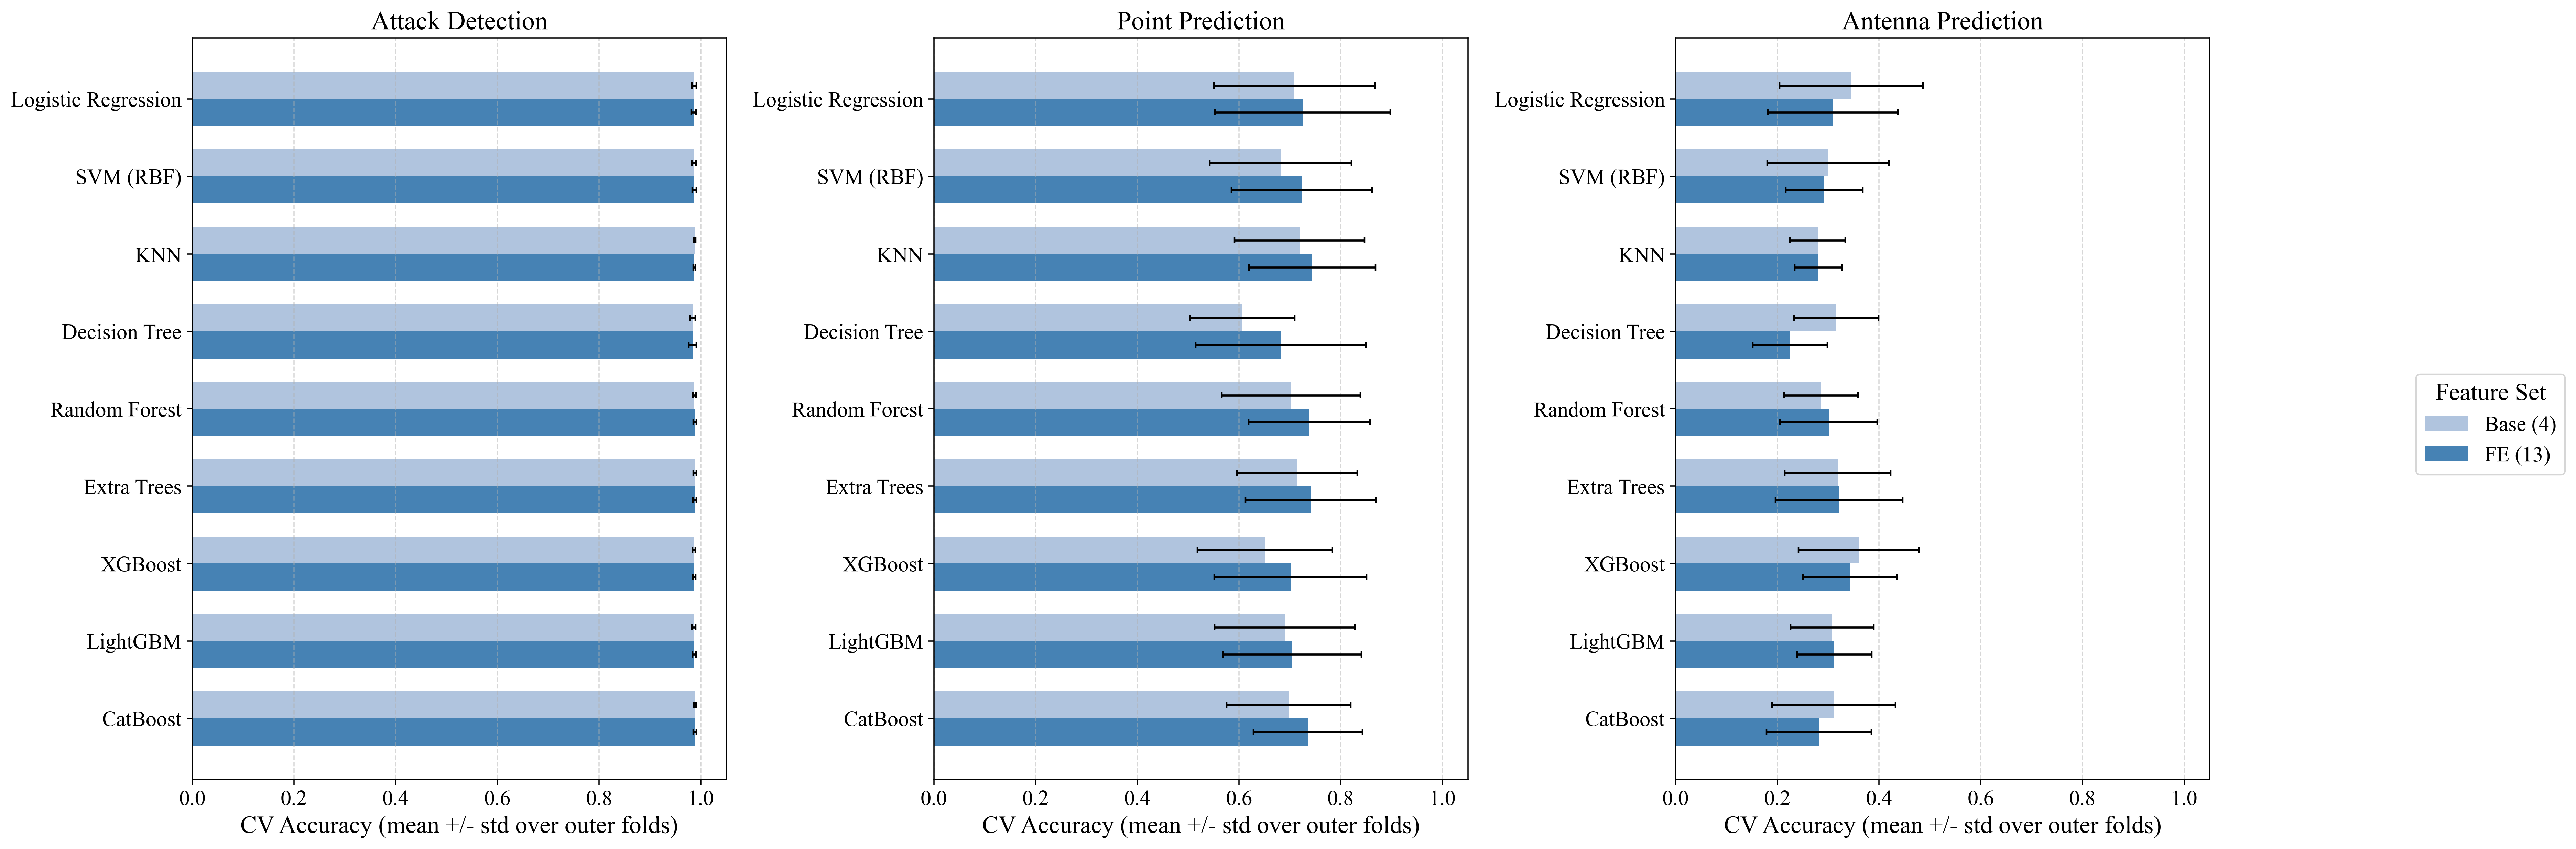

In [8]:
TASKS_ORDER_LABELS = [ep.TASKS[t]["label"] for t in ep.TASKS_ORDER]

def _plot_fig4(paper: bool):
    fig, axes = plt.subplots(1, 3, figsize=(22, 8))
    for ax, task_label in zip(axes, TASKS_ORDER_LABELS):
        sub = results_df[results_df.Task == task_label]
        models = list(ep.MODEL_CONFIGS.keys())
        y_pos = np.arange(len(models))
        width = 0.35
        for offset, (fs_label, color) in zip([-1, 1], [("Base (4)", "#B0C4DE"), ("FE (13)", "#4682B4")]):
            fs_sub = sub[sub["Feature Set"] == fs_label].set_index("Model").reindex(models)
            ax.barh(y_pos + offset * width / 2, fs_sub["Acc Mean"], height=width,
                    xerr=fs_sub["Acc Std"], color=color, label=fs_label, capsize=2)
        ax.set_yticks(y_pos)
        ax.set_yticklabels(models)
        # paper (F4): no title at all; internal: task name (never had a model name here)
        ax.set_title("" if paper else task_label)
        ax.set_xlabel("CV Accuracy (mean +/- std over outer folds)")
        ax.set_xlim(0, 1.05)
        ax.invert_yaxis()
        ax.grid(True, axis="x", linestyle="--", alpha=0.5)
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, title="Feature Set", loc="center left", bbox_to_anchor=(1.0, 0.5))
    plt.tight_layout(rect=[0, 0, 0.93, 1])
    return fig

fig_internal = _plot_fig4(paper=False)
fig_internal.savefig(INTERNAL_FIGURES_DIR / "fig4_comparison.png", bbox_inches="tight")
plt.show()

fig_paper = _plot_fig4(paper=True)
fig_paper.savefig(FIGURES_DIR / "fig4_comparison.png", bbox_inches="tight")
plt.close(fig_paper)

## 9. Winner Summary & OOF Confusion Matrices (Fig. 7-9)

The winner per task is the (model, feature set) combination with the highest **pooled**
OOF accuracy. Confusion matrices are built from the pooled OOF predictions, so
`trace(CM)/sum(CM)` reproduces `table1_primary.csv`'s Pooled Acc exactly (acceptance
check #2, asserted below).

In [9]:
winners = {}
for task in ep.TASKS_ORDER:
    task_label = ep.TASKS[task]["label"]
    sub = results_df[results_df.Task == task_label].sort_values("Pooled Acc", ascending=False)
    best = sub.iloc[0]
    winners[task] = (best["Model"], best["Feature Set"])
    print(f"{task_label:<22} winner={best['Model']} ({best['Feature Set']}) — pooled_acc={best['Pooled Acc']:.4f}")

Attack Detection       winner=CatBoost (FE (13)) — pooled_acc=0.9883
Point Prediction       winner=KNN (FE (13)) — pooled_acc=0.7426
Antenna Prediction     winner=XGBoost (Base (4)) — pooled_acc=0.3625


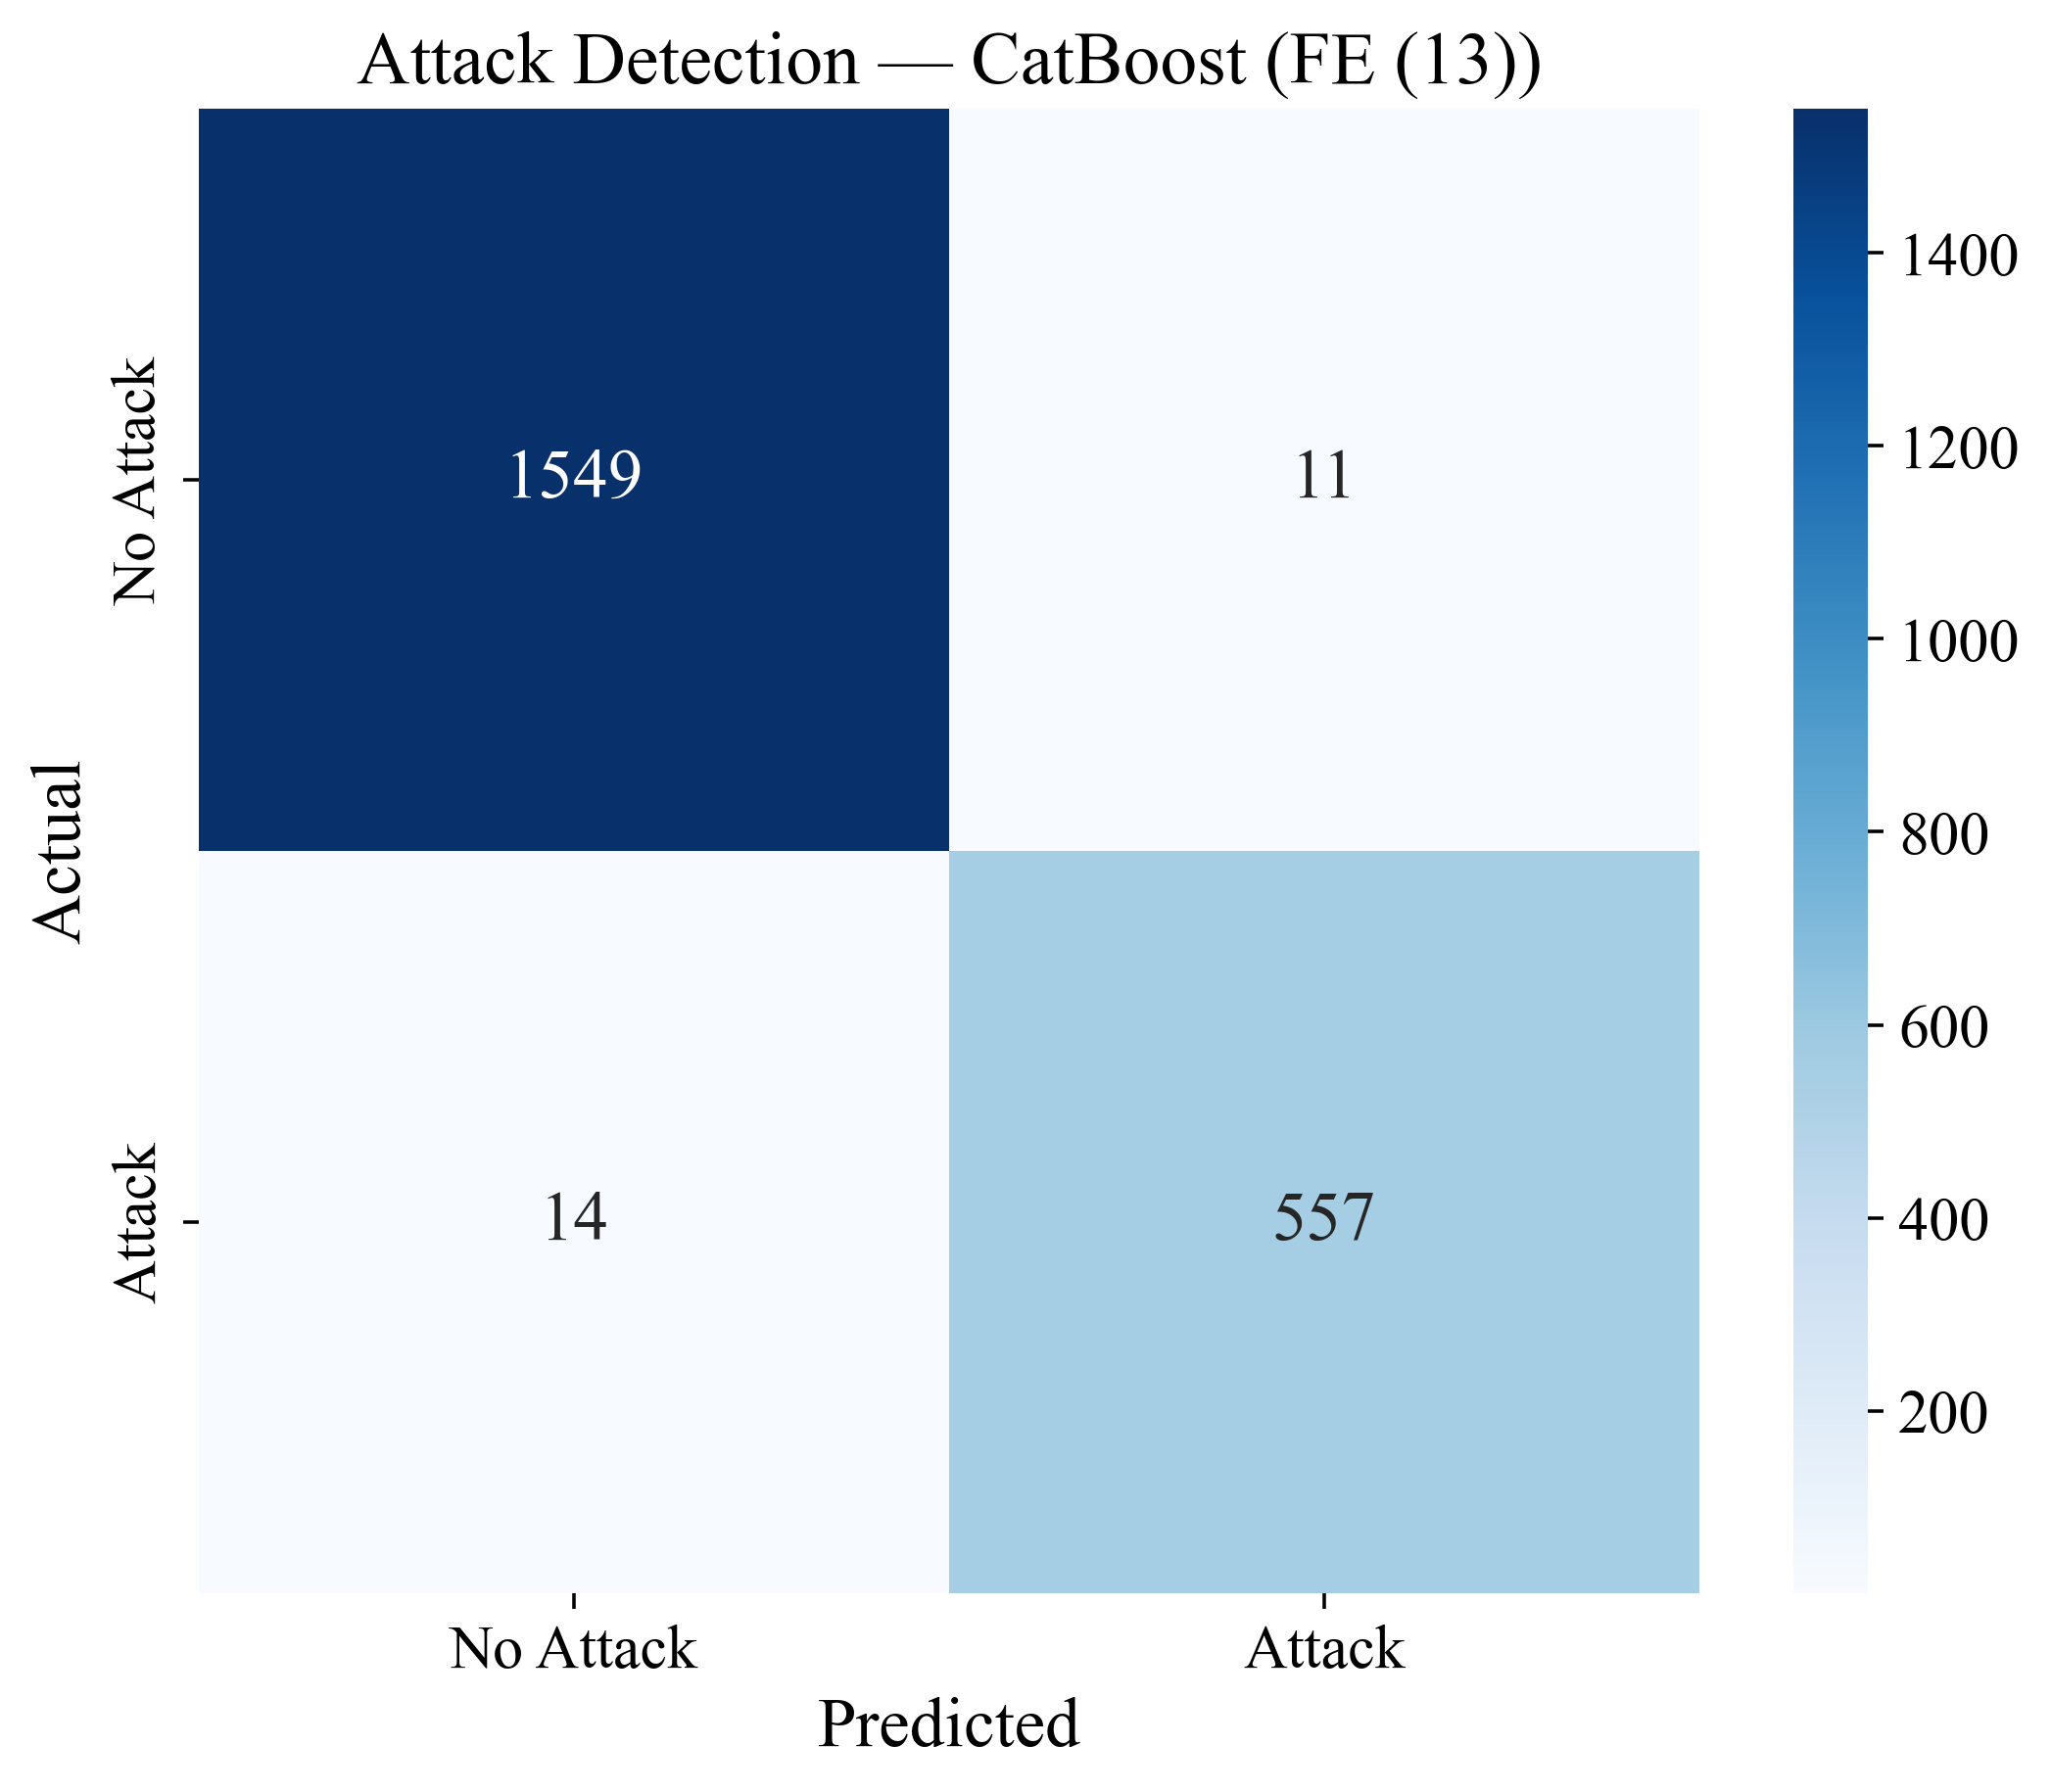

Attack Detection: trace/sum=0.988268 == table1 Pooled Acc=0.988268  OK


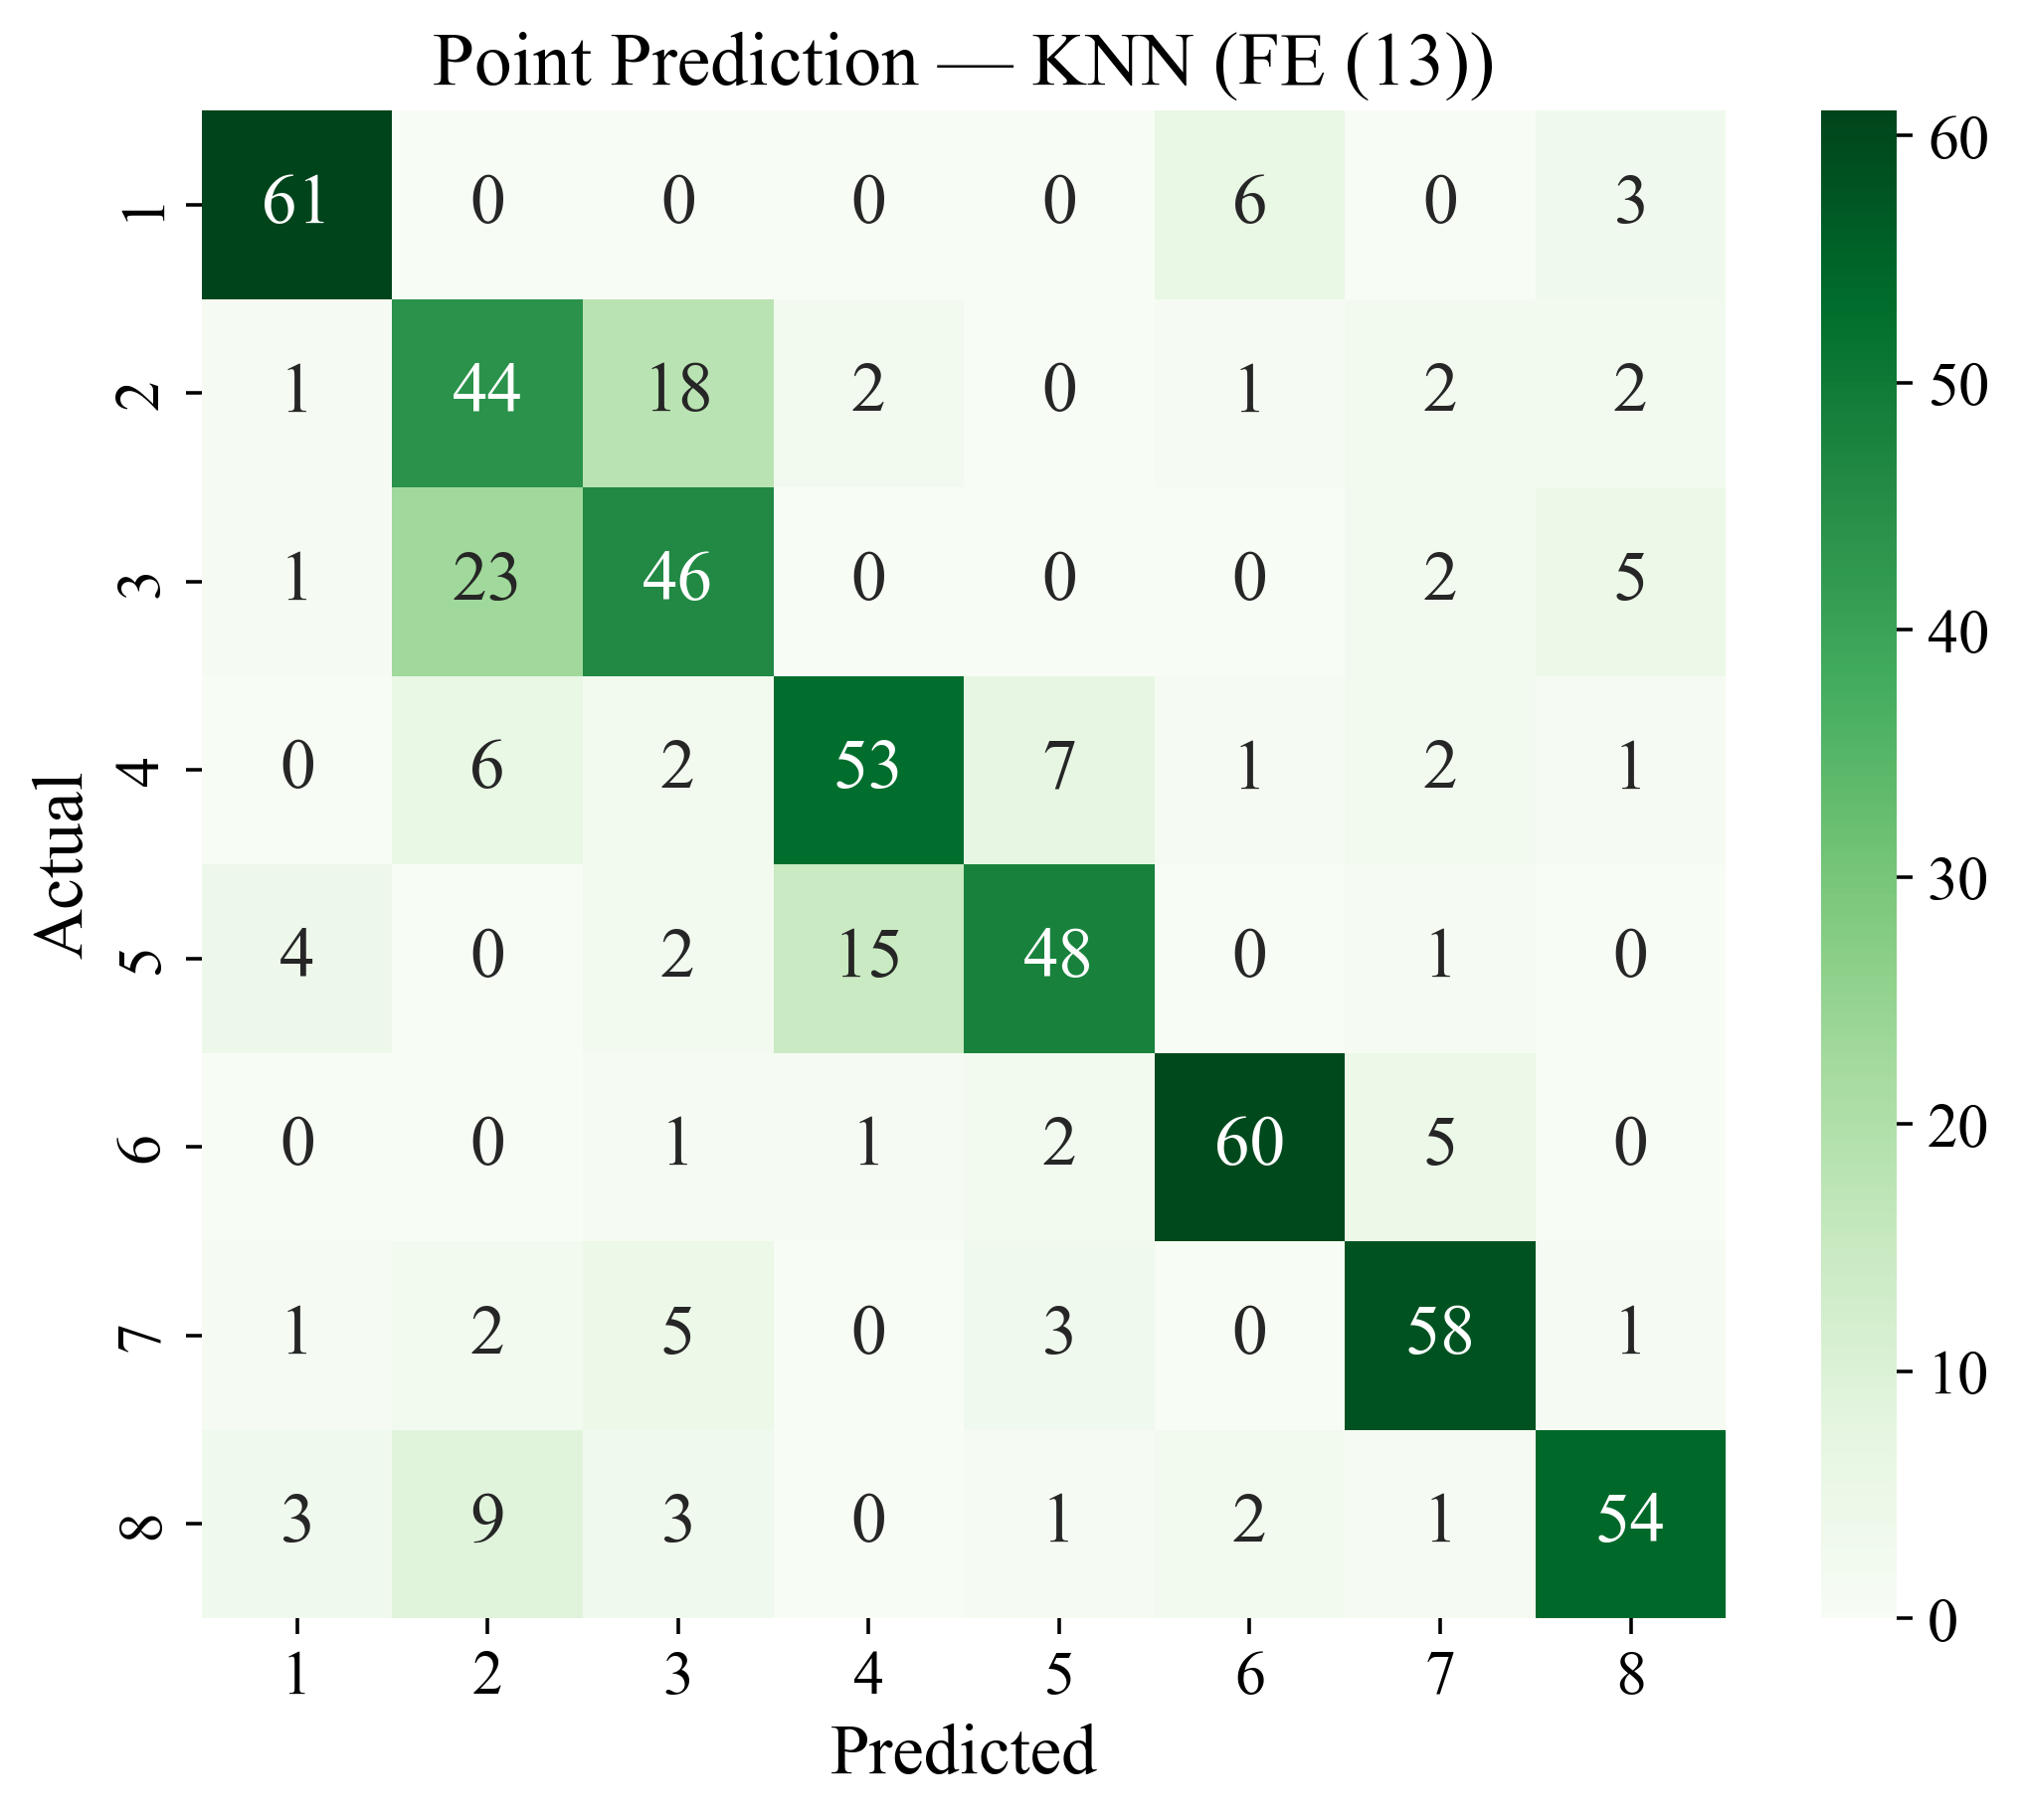

Point Prediction: trace/sum=0.742557 == table1 Pooled Acc=0.742557  OK


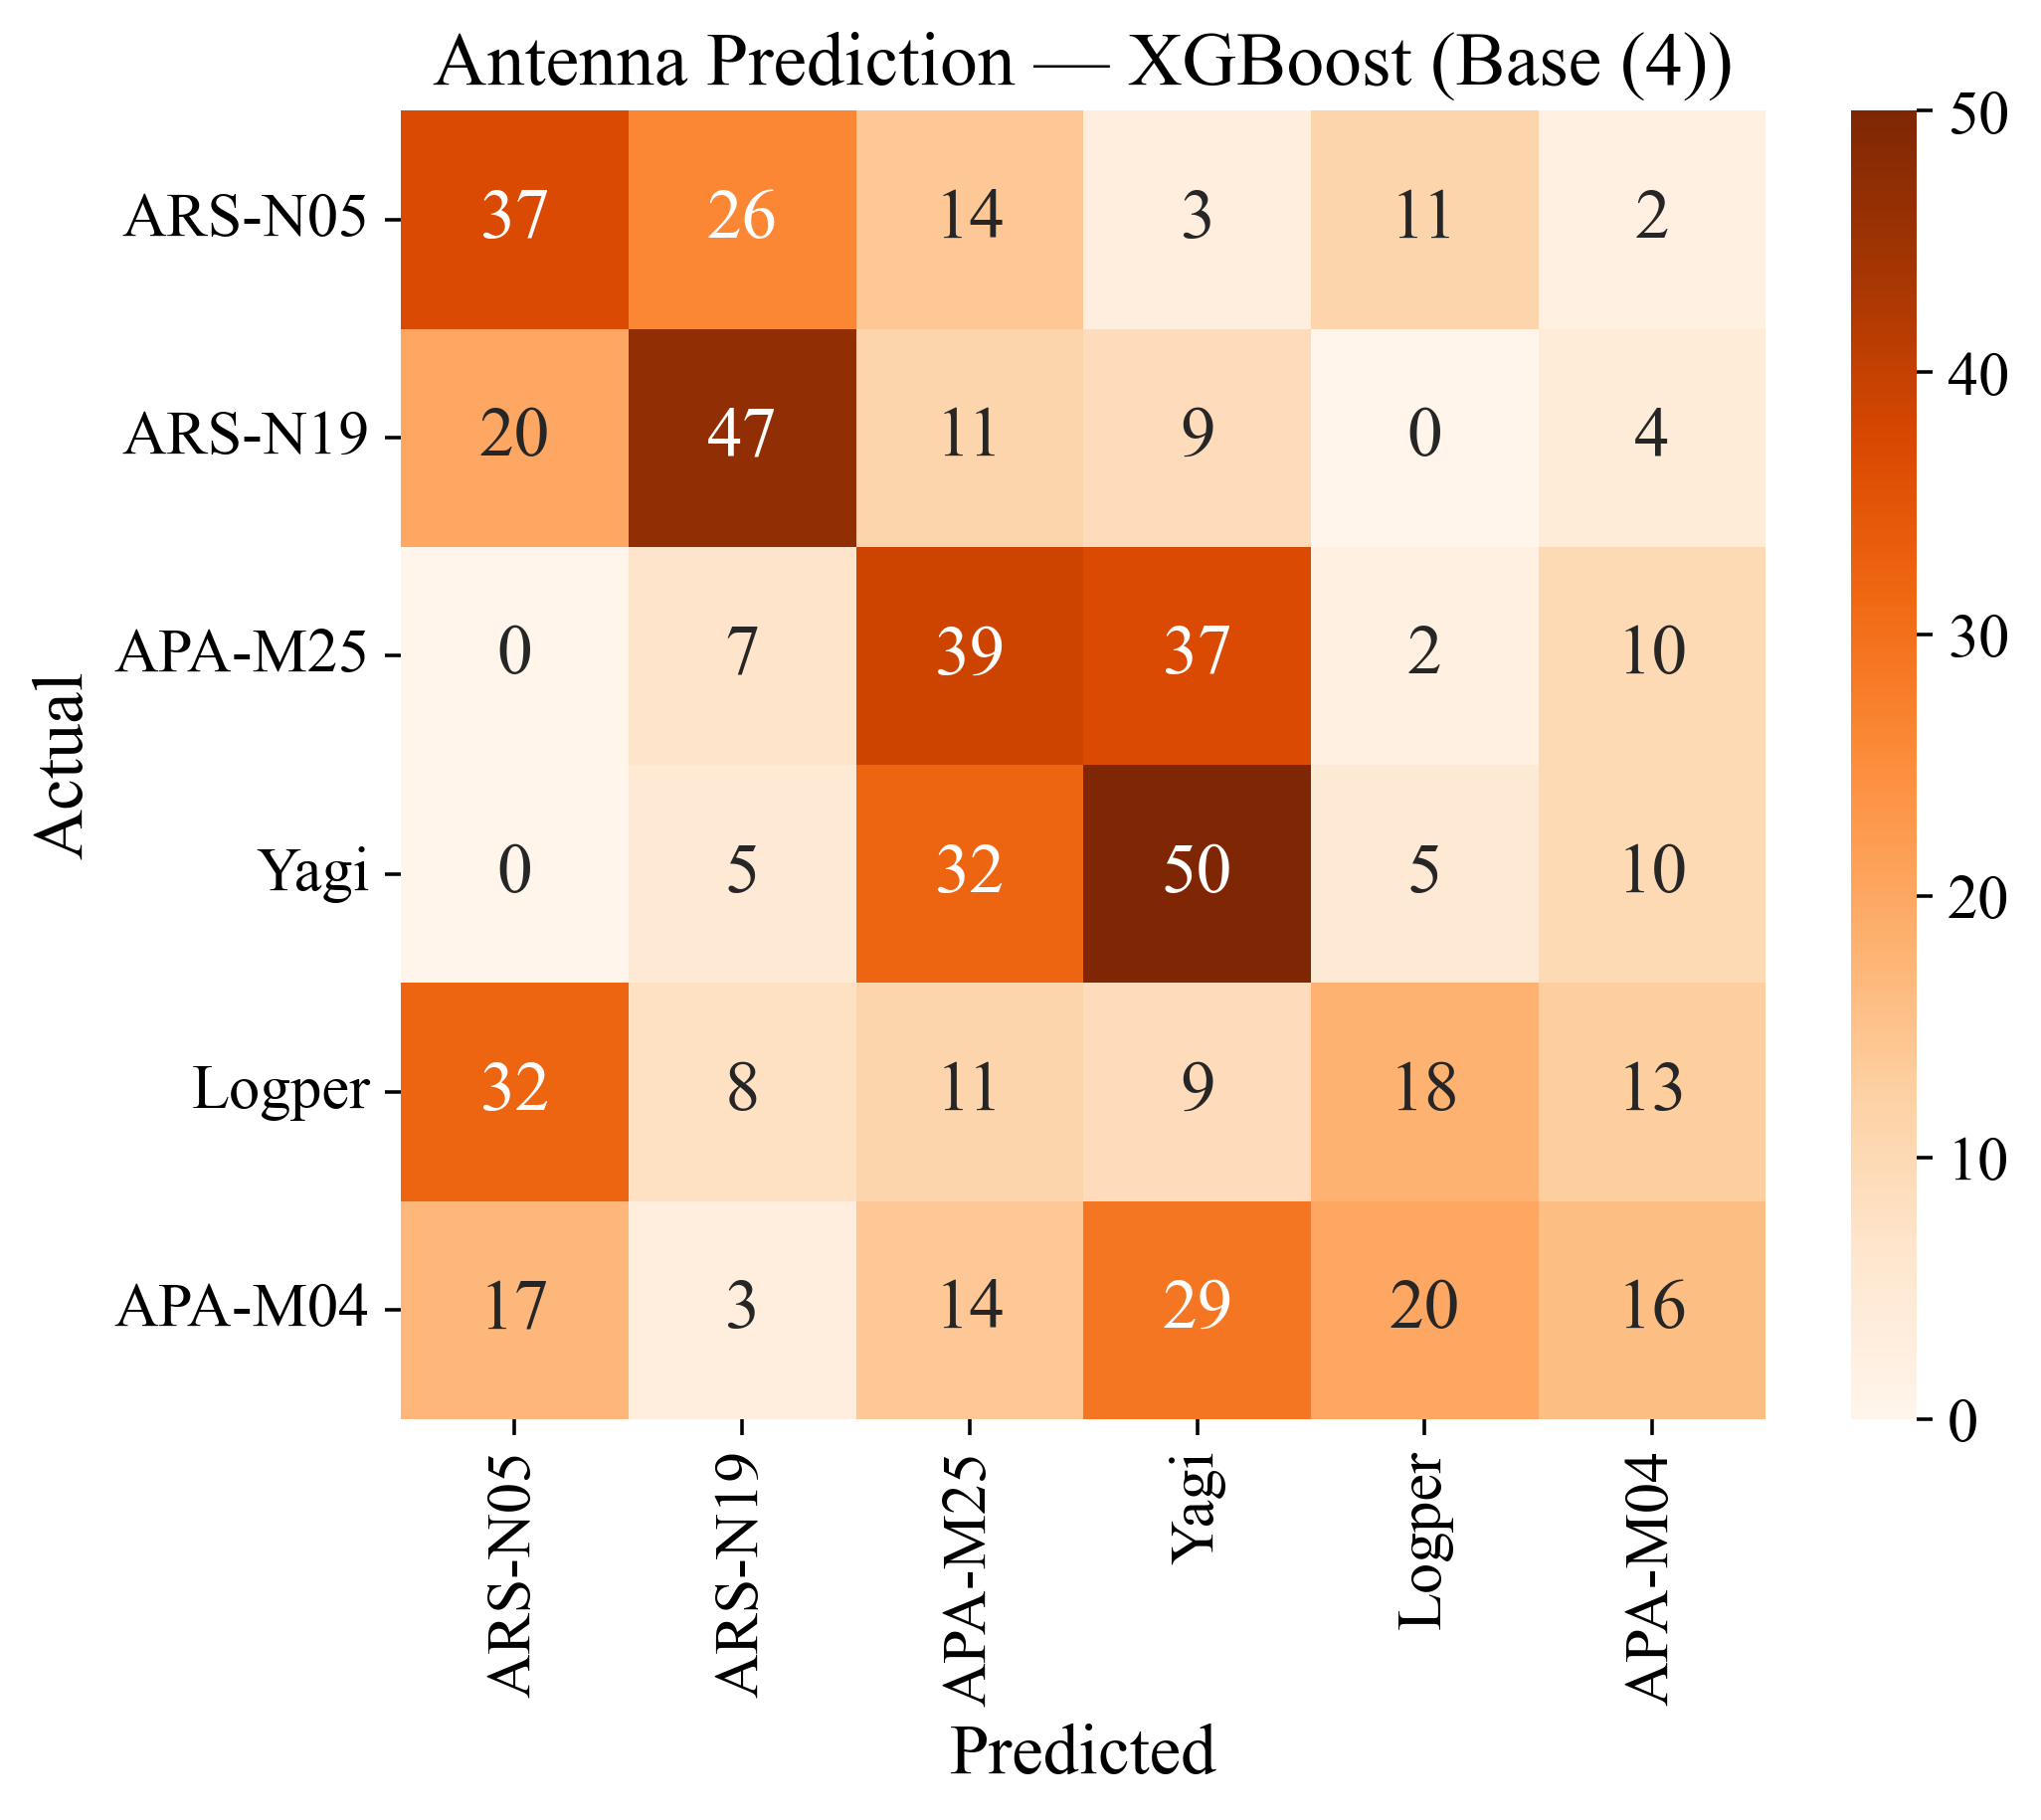

Antenna Prediction: trace/sum=0.362522 == table1 Pooled Acc=0.362522  OK


In [10]:
CM_SPECS = {
    "attack":  dict(fname="fig7_cm_attack.png",  labels=[0, 1], tick_labels=["No Attack", "Attack"], cmap="Blues"),
    "point":   dict(fname="fig8_cm_point.png",   labels=list(range(1, 9)), tick_labels=list(range(1, 9)), cmap="Greens"),
    "antenna": dict(fname="fig9_cm_antenna.png", labels=list(range(1, 7)), tick_labels=ep.ANTENNA_SHORT, cmap="Oranges"),
}

for task in ep.TASKS_ORDER:
    task_label = ep.TASKS[task]["label"]
    model_name, fs_label = winners[task]
    res = oof_store[(model_name, fs_label, task)]
    spec_cm = CM_SPECS[task]
    title = f"{task_label} — {model_name} ({fs_label})"

    # internal version: full title (task + winning model + feature set)
    fig, cm = ep.plot_confusion(
        res["oof_true"], res["oof_pred"], labels=spec_cm["labels"], title=title,
        path=INTERNAL_FIGURES_DIR / spec_cm["fname"], cmap=spec_cm["cmap"],
        tick_labels=spec_cm["tick_labels"], paper=False,
    )
    plt.show()

    # paper version (F4): no title at all, axis labels only
    fig_paper, _ = ep.plot_confusion(
        res["oof_true"], res["oof_pred"], labels=spec_cm["labels"], title=title,
        path=FIGURES_DIR / spec_cm["fname"], cmap=spec_cm["cmap"],
        tick_labels=spec_cm["tick_labels"], paper=True,
    )
    plt.close(fig_paper)

    pooled_from_cm = cm.trace() / cm.sum()
    fs_col = "Base" if fs_label.startswith("Base") else "FE"
    table1_acc = table1_df.loc[model_name, f"{task_label} Pooled Acc ({fs_col})"]
    assert abs(pooled_from_cm - table1_acc) < 1e-9, (task, pooled_from_cm, table1_acc)
    print(f"{task_label}: trace/sum={pooled_from_cm:.6f} == table1 Pooled Acc={table1_acc:.6f}  OK")

## 10. Fig. 5 — Accuracy vs `n_estimators` for the Winners

For each task's winning model, if it has an `n_estimators` hyperparameter, scan it with
the other hyperparameters fixed to the most frequent `best_params_` across outer folds
(`eval_protocol.most_frequent_params`), scored with the **primary grouped CV**
(no inner tuning — just `cross_val_score` under the same `LeaveOneGroupOut` protocol).

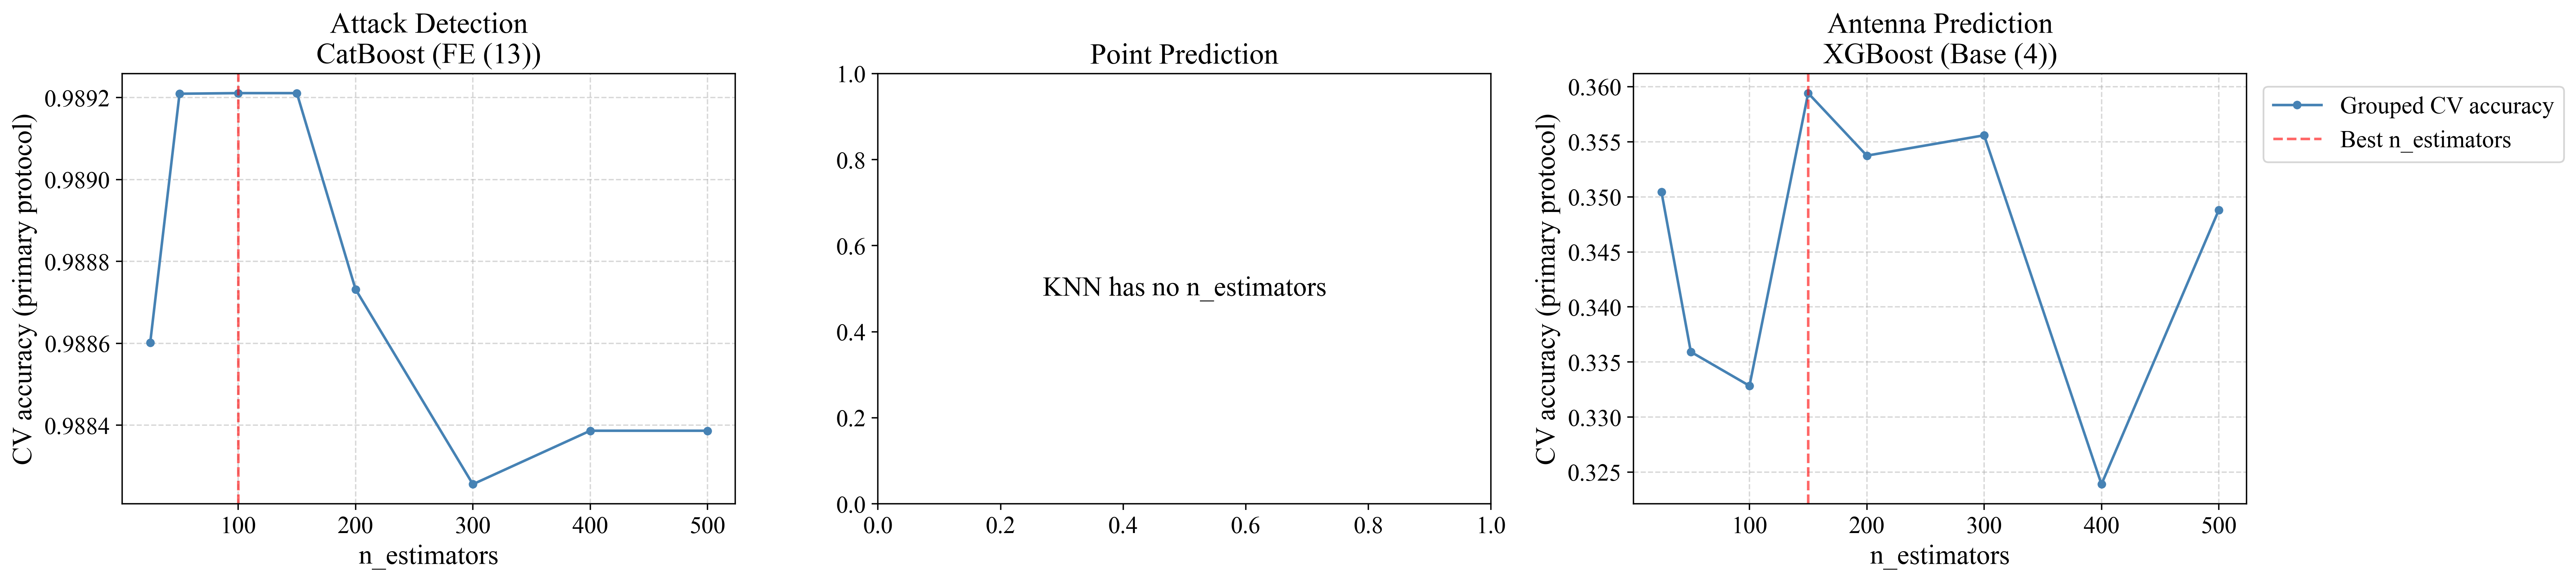

In [11]:
from sklearn.model_selection import cross_val_score

n_estimators_range = [25, 50, 100, 150, 200, 300, 400, 500]

# --- compute once ---
fig5_data = {}
for task in ep.TASKS_ORDER:
    task_label = ep.TASKS[task]["label"]
    model_name, fs_label = winners[task]
    cfg = ep.MODEL_CONFIGS[model_name]
    if "n_estimators" not in cfg["grid"]:
        fig5_data[task] = None
        continue

    spec = ep.TASKS[task]
    sub = dataset[spec["rows"](dataset)].reset_index(drop=True)
    feat_cols = FEATURE_SETS[fs_label]
    X, y = sub[feat_cols], sub[spec["y_col"]]
    outer_cv, groups = ep.get_outer_cv_and_groups("primary", task, sub)
    is_multiclass = task in ("point", "antenna")

    res = oof_store[(model_name, fs_label, task)]
    fixed = ep.most_frequent_params(res["best_params_per_fold"])
    n_key = "model__n_estimators" if ep.MODEL_CONFIGS[model_name]["scale"] else "n_estimators"
    fixed_others = {k: v for k, v in fixed.items() if k != n_key}

    scores = []
    for n in n_estimators_range:
        params = dict(fixed_others)
        params[n_key] = n
        est = ep.make_estimator(model_name, is_multiclass, params=params)
        cv_scores = cross_val_score(est, X, y, groups=groups, cv=outer_cv, n_jobs=-1)
        scores.append(cv_scores.mean())
    best_n = n_estimators_range[int(np.argmax(scores))]
    fig5_data[task] = {"model_name": model_name, "fs_label": fs_label, "scores": scores, "best_n": best_n}

# --- plot twice (internal with model names, paper without) from the cached scores ---
def _plot_fig5(paper: bool):
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    for ax, task in zip(axes, ep.TASKS_ORDER):
        task_label = ep.TASKS[task]["label"]
        d = fig5_data[task]
        if d is None:
            model_name, _ = winners[task]
            ax.text(0.5, 0.5, "n/a" if paper else f"{model_name} has no n_estimators",
                     ha="center", va="center", transform=ax.transAxes)
            ax.set_title("" if paper else task_label)
            continue
        ax.plot(n_estimators_range, d["scores"], marker="o", markersize=4, color="#4682B4", label="Grouped CV accuracy")
        ax.axvline(d["best_n"], color="red", linestyle="--", alpha=0.6, label="Best n_estimators")
        # paper (F4): task name only, no model name; internal: task + winning model
        ax.set_title(task_label if paper else f"{task_label}\n{d['model_name']} ({d['fs_label']})")
        ax.set_xlabel("n_estimators")
        ax.set_ylabel("CV accuracy (primary protocol)")
        ax.grid(True, linestyle="--", alpha=0.5)
    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc="center left", bbox_to_anchor=(0.92, 0.77))
    plt.tight_layout(rect=[0, 0, 0.93, 1])
    return fig

fig_internal = _plot_fig5(paper=False)
fig_internal.savefig(INTERNAL_FIGURES_DIR / "fig5_n_estimators.png", bbox_inches="tight")
plt.show()

fig_paper = _plot_fig5(paper=True)
fig_paper.savefig(FIGURES_DIR / "fig5_n_estimators.png", bbox_inches="tight")
plt.close(fig_paper)

## 11. Fig. 6 — Permutation Importance (averaged over outer test folds)

Permutation importance is computed on each outer fold's held-out test data using that
fold's own winning hyperparameters, then averaged — so importance is measured
out-of-sample throughout, consistent with the rest of the protocol.

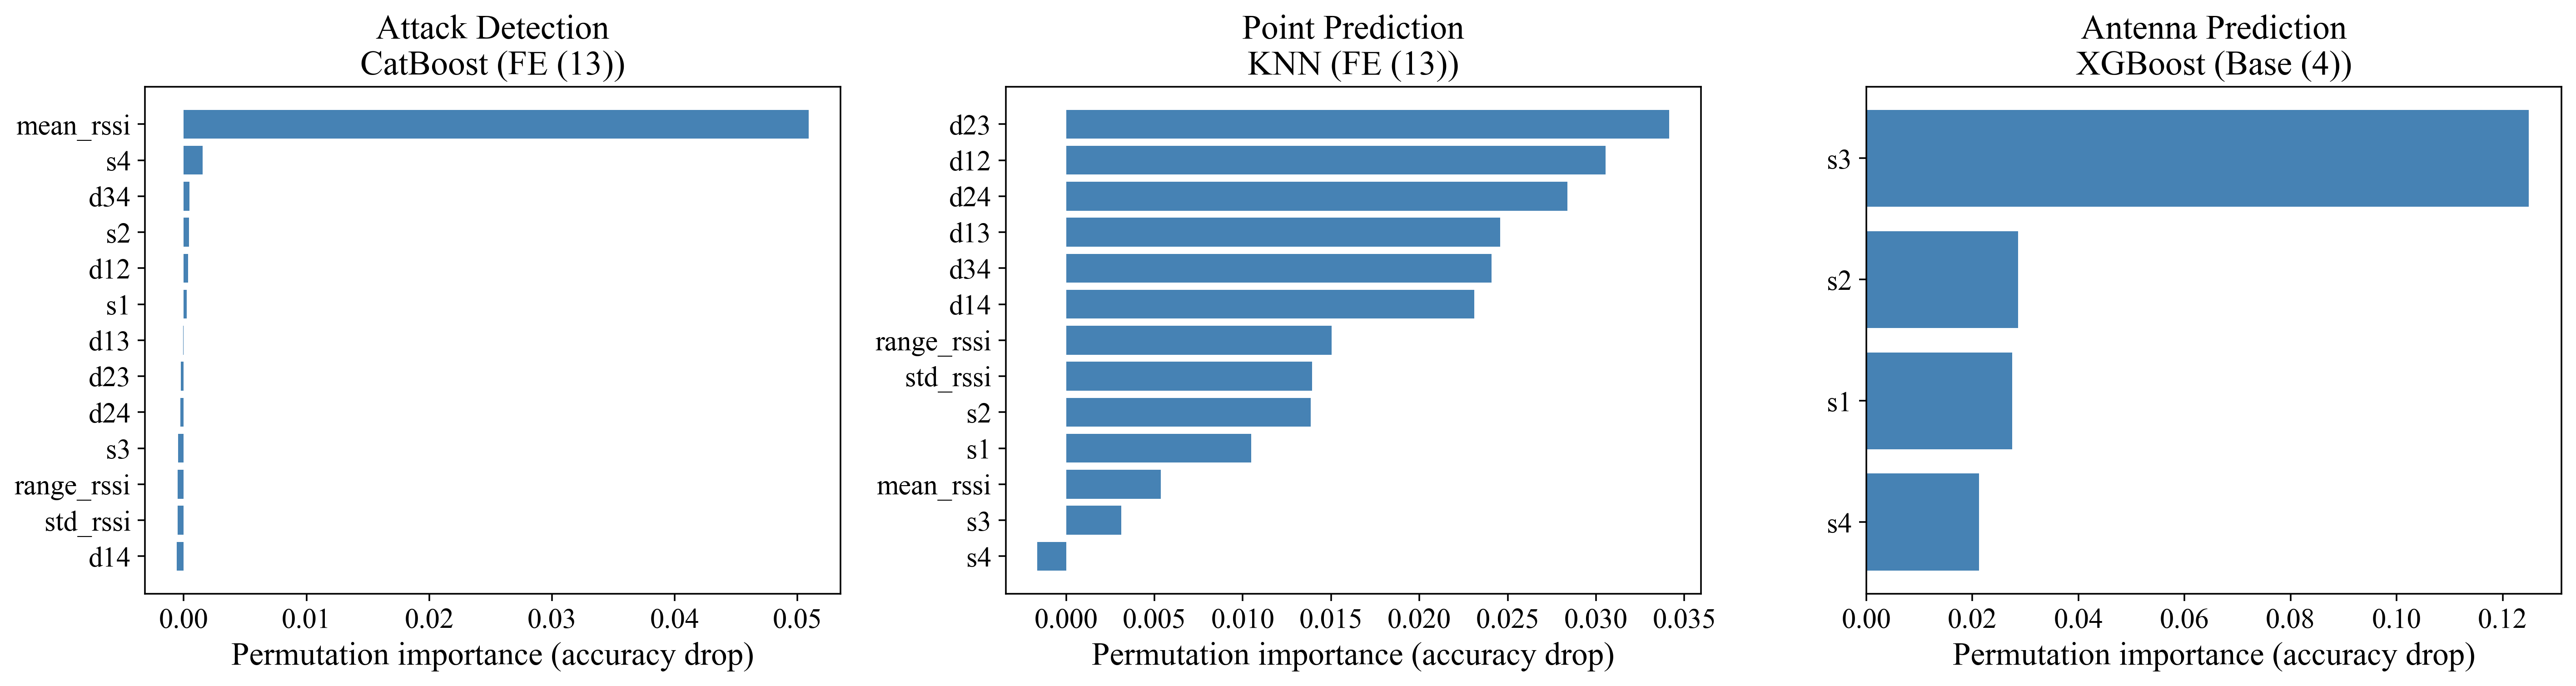

In [12]:
# --- compute once ---
fig6_data = {}
for task in ep.TASKS_ORDER:
    model_name, fs_label = winners[task]
    spec = ep.TASKS[task]
    sub = dataset[spec["rows"](dataset)].reset_index(drop=True)
    feat_cols = FEATURE_SETS[fs_label]
    X, y = sub[feat_cols], sub[spec["y_col"]]
    outer_cv, groups = ep.get_outer_cv_and_groups("primary", task, sub)
    is_multiclass = task in ("point", "antenna")

    res = oof_store[(model_name, fs_label, task)]
    importances = ep.permutation_importance_oof(
        model_name, X, y, groups, outer_cv, res["best_params_per_fold"],
        is_multiclass=is_multiclass, n_repeats=10,
    ).sort_values()
    fig6_data[task] = {"model_name": model_name, "fs_label": fs_label, "importances": importances}

# --- plot twice (internal with model names, paper without) ---
def _plot_fig6(paper: bool):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, task in zip(axes, ep.TASKS_ORDER):
        task_label = ep.TASKS[task]["label"]
        d = fig6_data[task]
        ax.barh(d["importances"].index, d["importances"].values, color="#4682B4")
        ax.set_xlabel("Permutation importance (accuracy drop)")
        # paper (F4): task name only, no model name; internal: task + winning model
        ax.set_title(task_label if paper else f"{task_label}\n{d['model_name']} ({d['fs_label']})")
    plt.tight_layout()
    return fig

fig_internal = _plot_fig6(paper=False)
fig_internal.savefig(INTERNAL_FIGURES_DIR / "fig6_importance.png", bbox_inches="tight")
plt.show()

fig_paper = _plot_fig6(paper=True)
fig_paper.savefig(FIGURES_DIR / "fig6_importance.png", bbox_inches="tight")
plt.close(fig_paper)

## 12. Acceptance Checks Recap

1. Group-overlap: asserted inline inside every `nested_cv()` call (section 6) via
   `eval_protocol._assert_no_group_overlap`, for both outer and inner splits.
2. Confusion-matrix / Table-1 consistency: asserted inline in section 9.
3. Sanity ranges (row counts, imputed share, rows/session) printed in section 2.

In [13]:
assert info.n_rows == 2131, info.n_rows
assert info.n_attack_rows == 571, info.n_attack_rows
assert info.n_sessions_attack == 48, info.n_sessions_attack
assert all(0.30 <= s <= 0.35 for s in info.imputed_share.values()), info.imputed_share
print("All dataset-level sanity checks passed.")

All dataset-level sanity checks passed.
